# 7. Elección óptima de N (longitud del n-grama) para el análisis simbólico del hipnograma

Para tratar el hipnograma como un lenguaje y entrenar embeddings tipo Word2Vec, necesitamos primero decidir la longitud del **token** (n-grama). Este notebook elige el N óptimo en el dataset unificado (127 pacientes sanos: CAP 16 + EDF 82 + SCO 29) usando **tres criterios independientes**:

1. **Ley de Zipf (β):** para cada N construimos los n-gramas, ordenamos por frecuencia descendente y ajustamos $\log_{10}(\text{frecuencia}) = a - \beta\,\log_{10}(\text{rango})$. Una distribución tipo lenguaje natural tiene $\beta\approx 1$.

2. **Calidad del ajuste (R²):** además del valor de $\beta$ nos interesa cuán bien describe la recta a los datos. R² alto = ley de potencia limpia (no ruido).

3. **Cobertura de los bloques continuos de S2:** la fase 2 del sueño aparece en bloques temporales (épocas consecutivas). Una ventana de tamaño N que cabe dentro del bloque típico de S2 captura "una unidad fisiológica completa". Medimos qué fracción de los bloques de S2 tiene longitud ≥ N.

Combinamos los tres criterios en un ranking y elegimos el N que mejor balancea los tres.

**Salidas** (en **imagenes/zipf/** y **estadisticas/**):
- **zipf_loglog_grid.png** — paneles log-log para varios N.
- **zipf_beta_vs_n.png** — β en función de N (global y por dataset).
- **duracion_s2_histograma.png** — distribución de duraciones de bloques S2.
- **justificacion_N_combinada.png** — β(N) con anclajes fisiológicos.
- **zipf_beta_por_n.csv**, **zipf_beta_por_n_por_dataset.csv** — β y R² por N.
- **duracion_s2_bloques.csv** — resumen de bloques continuos de S2.
- **seleccion_N_tabla.csv** — tabla del criterio combinado.


In [1]:
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

RAIZ = Path("..").resolve()
RUTA_CSV = RAIZ / "dataset/epocas_unificado.csv"
OUT_IMG  = RAIZ / "imagenes/zipf"
OUT_EST  = RAIZ / "estadisticas"
OUT_IMG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_CSV)
print(f"Pacientes: {df['paciente'].nunique()} | Épocas brutas: {len(df)}")

df = df[df['fase_num'] != 5].copy()
print(f"Épocas tras excluir Sin_clasificar: {len(df)}")

FASES_ESTUDIO = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 25, 35, 50, 100]

Pacientes: 127 | Épocas brutas: 112809
Épocas tras excluir Sin_clasificar: 110950


In [2]:
def secuencias_por_paciente(df_sub):
    """Devuelve dict {paciente: lista de fases (int)} respetando el orden temporal."""
    secs = {}
    for pac, g in df_sub.groupby("paciente", sort=False):
        secs[pac] = g.sort_values("epoca")["fase_num"].astype(int).tolist()
    return secs

def contar_ngramas(secuencias, n):
    """Concatena los n-gramas de todas las secuencias (sin cruzar pacientes) y los cuenta."""
    c = Counter()
    for seq in secuencias.values():
        if len(seq) < n:
            continue
        for i in range(len(seq) - n + 1):
            c[tuple(seq[i:i + n])] += 1
    return c

def ajustar_zipf(counter, min_rango=1, max_rango=None):
    """Ajusta log10(freq) = a + m * log10(rango); devuelve beta = -m, intercepto, R^2, n_únicos.
    Opcionalmente recorta al tramo [min_rango, max_rango] (1-indexed)."""
    if not counter:
        return dict(beta=np.nan, intercepto=np.nan, r2=np.nan, n_unicos=0, n_total=0)
    freqs = np.array([f for _, f in counter.most_common()], dtype=float)
    rangos = np.arange(1, len(freqs) + 1, dtype=float)
    lo = max(1, min_rango)
    hi = len(freqs) if max_rango is None else min(len(freqs), max_rango)
    if hi - lo + 1 < 5:
        return dict(beta=np.nan, intercepto=np.nan, r2=np.nan,
                    n_unicos=len(freqs), n_total=int(freqs.sum()))
    x = np.log10(rangos[lo - 1:hi])
    y = np.log10(freqs[lo - 1:hi])
    res = linregress(x, y)
    return dict(beta=float(-res.slope),
                intercepto=float(res.intercept),
                r2=float(res.rvalue ** 2),
                n_unicos=int(len(freqs)),
                n_total=int(freqs.sum()))

secs_todos = secuencias_por_paciente(df)
secs_por_ds = {ds: secuencias_por_paciente(g) for ds, g in df.groupby("dataset")}
print({k: len(v) for k, v in secs_por_ds.items()})

{'CAP': 16, 'EDF': 82, 'SCO': 29}


In [3]:
# Barrido global (todos los pacientes juntos)
filas_global = []
contadores_global = {}
for n in FASES_ESTUDIO:
    c = contar_ngramas(secs_todos, n)
    contadores_global[n] = c
    a = ajustar_zipf(c)
    a["N"] = n
    filas_global.append(a)

tabla_global = pd.DataFrame(filas_global)[["N", "beta", "r2", "n_unicos", "n_total"]]
tabla_global.to_csv(OUT_EST / "zipf_beta_por_n.csv", index=False)
print(tabla_global.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

  N   beta     r2  n_unicos  n_total
  1 1.1953 0.9798         5   110950
  2 2.8361 0.8016        25   110823
  3 2.5805 0.8860       102   110696
  4 2.1643 0.9406       316   110569
  5 1.8527 0.9664       793   110442
  6 1.5968 0.9775      1617   110315
  8 1.2502 0.9715      4393   110061
 10 1.0088 0.9518      8584   109807
 15 0.6687 0.8431     21711   109172
 20 0.5120 0.7510     33771   108537
 25 0.4178 0.6775     44121   107902
 35 0.3045 0.5706     60305   106632
 50 0.1998 0.4299     76524   104727
100 0.0591 0.1723     93451    98377


In [4]:
# Mismo barrido por dataset
filas_ds = []
for ds, secs in secs_por_ds.items():
    for n in FASES_ESTUDIO:
        c = contar_ngramas(secs, n)
        a = ajustar_zipf(c)
        a["N"] = n
        a["dataset"] = ds
        filas_ds.append(a)

tabla_ds = pd.DataFrame(filas_ds)[["dataset", "N", "beta", "r2", "n_unicos", "n_total"]]
tabla_ds.to_csv(OUT_EST / "zipf_beta_por_n_por_dataset.csv", index=False)

piv_beta = tabla_ds.pivot(index="N", columns="dataset", values="beta")
print("β por (N, dataset):")
print(piv_beta.round(4))

β por (N, dataset):
dataset     CAP     EDF     SCO
N                              
1        1.4213  1.2424  1.0680
2        2.5917  2.8143  2.4670
3        2.3775  2.5151  2.2156
4        1.9624  2.1180  1.8644
5        1.6982  1.8001  1.5797
6        1.5037  1.5590  1.3508
8        1.2526  1.2269  1.0251
10       1.0977  0.9906  0.8106
15       0.8657  0.6587  0.5282
20       0.7277  0.5086  0.3894
25       0.6331  0.4143  0.3109
35       0.5146  0.2956  0.2251
50       0.4178  0.1819  0.1416
100      0.1829  0.0408  0.0129


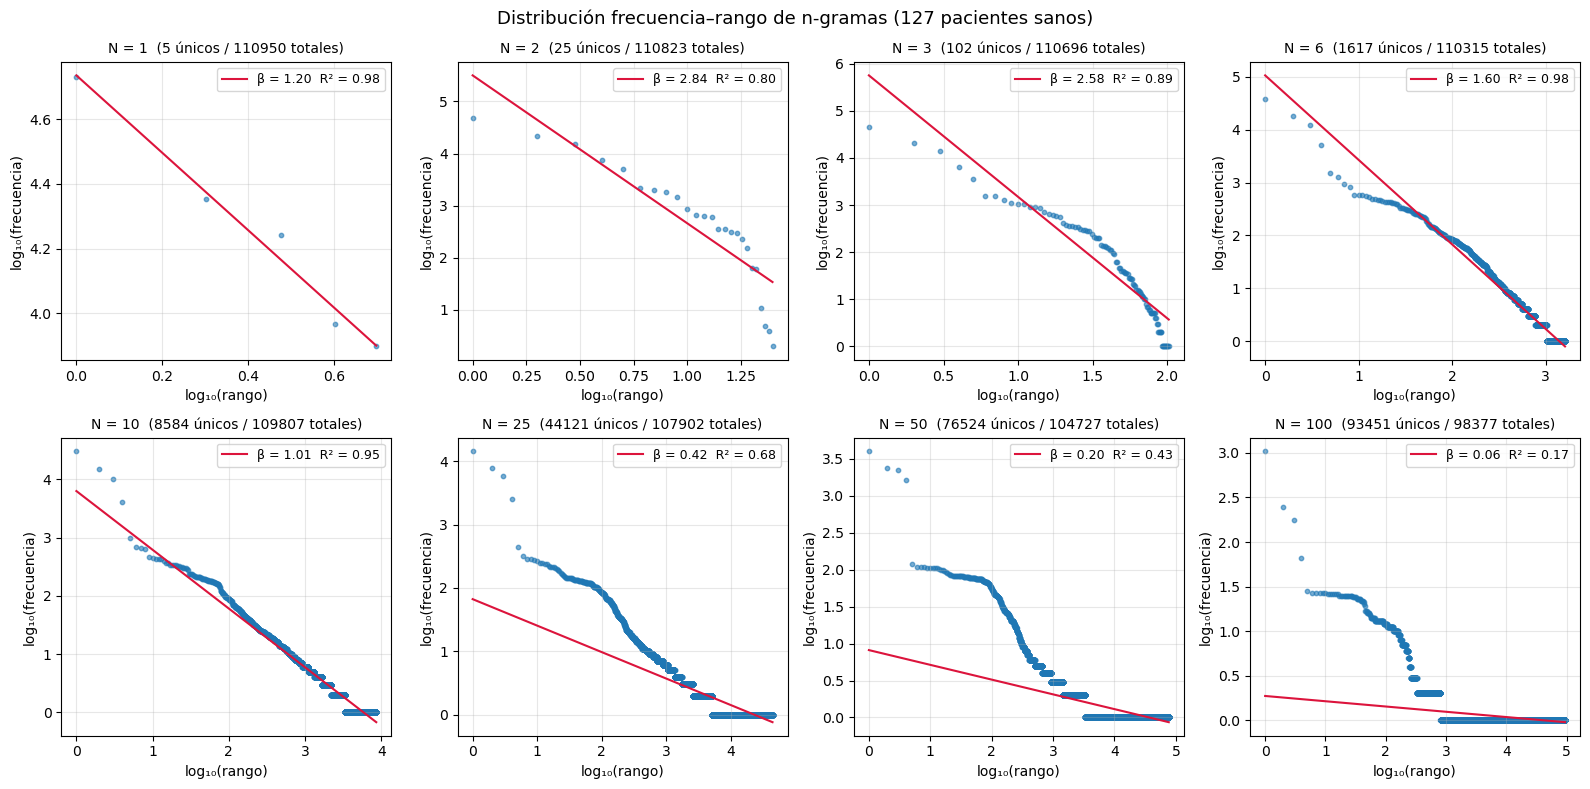

In [5]:
# Grid log-log para N seleccionados
N_VIS = [1, 2, 3, 6, 10, 25, 50, 100]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, n in zip(axes, N_VIS):
    c = contadores_global[n]
    freqs = np.array([f for _, f in c.most_common()], dtype=float)
    rangos = np.arange(1, len(freqs) + 1, dtype=float)
    ax.scatter(np.log10(rangos), np.log10(freqs), s=10, color="#1f77b4", alpha=0.6)
    aj = ajustar_zipf(c)
    if np.isfinite(aj["beta"]):
        xs = np.log10(rangos)
        ys = aj["intercepto"] - aj["beta"] * xs
        ax.plot(xs, ys, color="crimson", lw=1.5,
                label=f"β = {aj['beta']:.2f}  R² = {aj['r2']:.2f}")
        ax.legend(loc="upper right", fontsize=9)
    ax.set_title(f"N = {n}  ({aj['n_unicos']} únicos / {aj['n_total']} totales)", fontsize=10)
    ax.set_xlabel("log₁₀(rango)")
    ax.set_ylabel("log₁₀(frecuencia)")
    ax.grid(True, alpha=0.3)
fig.suptitle("Distribución frecuencia–rango de n-gramas (127 pacientes sanos)", fontsize=13)
fig.tight_layout()
fig.savefig(OUT_IMG / "zipf_loglog_grid.png", dpi=300, bbox_inches="tight")
plt.show()

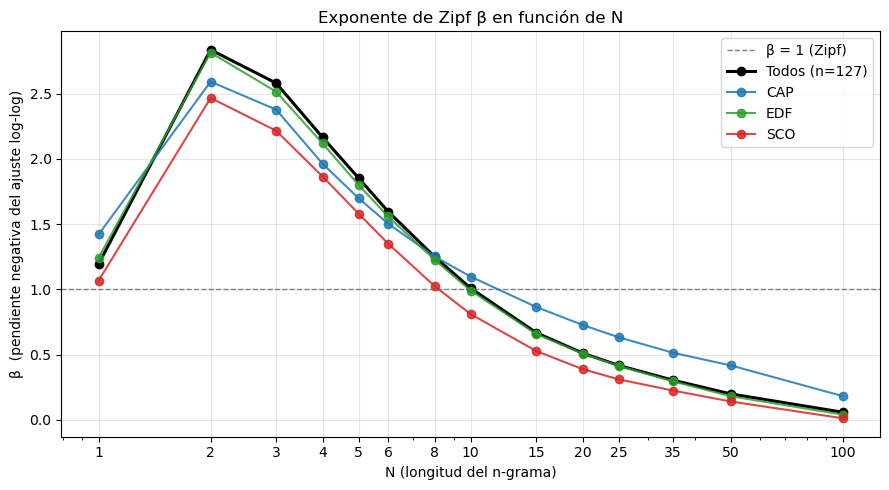

In [6]:
# β vs N — global y por dataset, con línea de referencia β=1 (Zipf)
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="β = 1 (Zipf)")

ax.plot(tabla_global["N"], tabla_global["beta"], marker="o", linewidth=2.2,
        color="black", label="Todos (n=127)")
colores_ds = {"CAP": "#1f77b4", "EDF": "#2ca02c", "SCO": "#d62728"}
for ds, sub in tabla_ds.groupby("dataset"):
    ax.plot(sub["N"], sub["beta"], marker="o", linewidth=1.5, alpha=0.85,
            color=colores_ds.get(ds, "orange"), label=f"{ds}")

ax.set_xscale("log")
ax.set_xticks(FASES_ESTUDIO)
ax.set_xticklabels(FASES_ESTUDIO)
ax.set_xlabel("N (longitud del n-grama)")
ax.set_ylabel("β  (pendiente negativa del ajuste log-log)")
ax.set_title("Exponente de Zipf β en función de N")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUT_IMG / "zipf_beta_vs_n.png", dpi=300, bbox_inches="tight")
plt.show()

## Pilar 2 — Duración de los bloques continuos de S2

Para cada paciente identificamos los **bloques continuos** de S2 (épocas consecutivas con **fase_num == 2**) y medimos su longitud. Si la longitud típica del bloque es del orden de N, entonces una ventana de tamaño N captura un episodio completo de S2 (la unidad fisiológica de la teoría).


In [7]:
def bloques_continuos(seq, fase):
    bloques = []
    i = 0
    while i < len(seq):
        if seq[i] != fase:
            i += 1
            continue
        ini = i
        while i < len(seq) and seq[i] == fase:
            i += 1
        bloques.append(i - ini)
    return bloques

filas_s2 = []
durs_global = []
durs_por_ds = {ds: [] for ds in secs_por_ds}
for ds, secs in secs_por_ds.items():
    for pac, seq in secs.items():
        d = bloques_continuos(seq, fase=2)
        durs_por_ds[ds].extend(d)
        durs_global.extend(d)
        filas_s2.append({"dataset": ds, "paciente": pac,
                          "n_bloques": len(d),
                          "media": float(np.mean(d)) if d else np.nan,
                          "mediana": float(np.median(d)) if d else np.nan})

import numpy as np
durs_global = np.array(durs_global)
pct = lambda a, p: float(np.percentile(a, p))
resumen_s2 = pd.DataFrame([
    {"dataset": ds,
     "n_bloques": len(d),
     "media": float(np.mean(d)),
     "mediana": float(np.median(d)),
     "p25": pct(np.array(d), 25),
     "p75": pct(np.array(d), 75),
     "p90": pct(np.array(d), 90)}
    for ds, d in durs_por_ds.items()
] + [
    {"dataset": "TODOS",
     "n_bloques": len(durs_global),
     "media": float(durs_global.mean()),
     "mediana": float(np.median(durs_global)),
     "p25": pct(durs_global, 25),
     "p75": pct(durs_global, 75),
     "p90": pct(durs_global, 90)}
])
resumen_s2.to_csv(OUT_EST / "duracion_s2_bloques.csv", index=False)
print(resumen_s2.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\nDuración media global en minutos: {durs_global.mean()*0.5:.2f} min")
print(f"Duración mediana global en minutos: {np.median(durs_global)*0.5:.2f} min")


dataset  n_bloques  media  mediana  p25   p75   p90
    CAP        272  23.85    14.00 6.00 37.00 57.00
    EDF       2900  12.55     5.00 2.00 17.00 35.00
    SCO       1265   8.55     4.00 1.00 10.00 22.00
  TODOS       4437  12.10     5.00 2.00 15.00 34.00

Duración media global en minutos: 6.05 min
Duración mediana global en minutos: 2.50 min


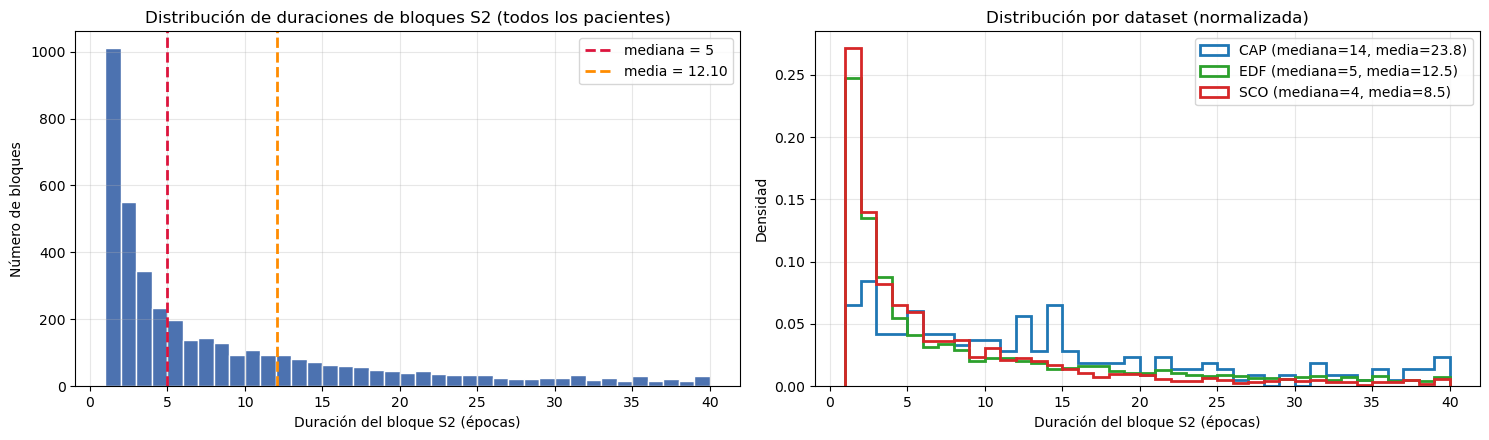

In [8]:
# Histograma de duraciones de S2 + líneas de candidatos para N
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax = axes[0]
bins = np.arange(1, 41)
ax.hist(durs_global, bins=bins, color="#4c72b0", edgecolor="white")
mediana = float(np.median(durs_global))
media = float(durs_global.mean())
ax.axvline(mediana, color="crimson", linestyle="--", linewidth=2,
           label=f"mediana = {mediana:.0f}")
ax.axvline(media, color="darkorange", linestyle="--", linewidth=2,
           label=f"media = {media:.2f}")
ax.set_xlabel("Duración del bloque S2 (épocas)")
ax.set_ylabel("Número de bloques")
ax.set_title("Distribución de duraciones de bloques S2 (todos los pacientes)")
ax.legend()
ax.grid(True, alpha=0.3)

# Por dataset
ax = axes[1]
colores_ds = {"CAP": "#1f77b4", "EDF": "#2ca02c", "SCO": "#d62728"}
for ds, d in durs_por_ds.items():
    ax.hist(d, bins=bins, density=True, histtype="step",
            color=colores_ds.get(ds, "gray"), linewidth=2,
            label=f"{ds} (mediana={np.median(d):.0f}, media={np.mean(d):.1f})")
ax.set_xlabel("Duración del bloque S2 (épocas)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución por dataset (normalizada)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_IMG / "duracion_s2_histograma.png", dpi=300, bbox_inches="tight")
plt.show()


## Pilar 3 — Criterio combinado para elegir N

Construimos una tabla con N candidatos $(5, 6, 7, 8, 9, 10, 12, 15)$ y los siguientes criterios:

| Criterio | Significado | Ideal |
|---|---|---|
| **β** | Pendiente Zipf global | cerca de 1 |
| **\|β−1\|** | Distancia a Zipf | mínima |
| **R²** | Calidad del ajuste log-log | ≥ 0.95 |
| **cobertura S2 (%)** | % bloques S2 con longitud ≥ N | ≥ 40 % (la ventana cabe en mayoría de bloques) |
| **n únicos / n totales** | densidad combinatoria | "Ni demasiado denso (todo se repite) ni demasiado disperso (todo es único)" |

Idealmente queremos un N que esté **bien ranqueado en todos los criterios simultáneamente** (no solo en uno).


In [9]:
CANDIDATOS = [5, 6, 7, 8, 9, 10, 12, 15]

# Asegurarse de tener contadores para todos los candidatos
for n in CANDIDATOS:
    if n not in contadores_global:
        contadores_global[n] = contar_ngramas(secs_todos, n)

filas = []
for n in CANDIDATOS:
    c = contadores_global[n]
    aj = ajustar_zipf(c)
    cobertura = float((durs_global >= n).mean()) * 100
    filas.append({
        "N": n,
        "beta": aj["beta"],
        "|beta-1|": abs(aj["beta"] - 1.0),
        "R2": aj["r2"],
        "cobertura_S2_%": cobertura,
        "n_unicos": aj["n_unicos"],
        "n_totales": aj["n_total"],
        "diversidad": aj["n_unicos"] / aj["n_total"],
    })
tabla_sel = pd.DataFrame(filas)

# Ranking compuesto: posición media en los 3 criterios principales
tabla_sel["rk_betaZipf"] = tabla_sel["|beta-1|"].rank(method="min")
tabla_sel["rk_R2"]       = (-tabla_sel["R2"]).rank(method="min")
tabla_sel["rk_cobertura"]= (-tabla_sel["cobertura_S2_%"]).rank(method="min")
tabla_sel["score_medio"] = tabla_sel[["rk_betaZipf", "rk_R2", "rk_cobertura"]].mean(axis=1)
tabla_sel = tabla_sel.sort_values("score_medio").reset_index(drop=True)

tabla_sel.to_csv(OUT_EST / "seleccion_N_tabla.csv", index=False)
print(tabla_sel.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\n>>> N recomendado (mejor score combinado): N = {int(tabla_sel.iloc[0]['N'])}")


 N   beta  |beta-1|     R2  cobertura_S2_%  n_unicos  n_totales  diversidad  rk_betaZipf  rk_R2  rk_cobertura  score_medio
 6 1.5968    0.5968 0.9775         47.3293      1617     110315      0.0147       7.0000 1.0000        2.0000       3.3333
 7 1.4046    0.4046 0.9772         44.2416      2815     110188      0.0255       6.0000 2.0000        3.0000       3.6667
 8 1.2502    0.2502 0.9715         40.9962      4393     110061      0.0399       4.0000 3.0000        4.0000       3.6667
 9 1.1213    0.1213 0.9641         38.0663      6308     109934      0.0574       2.0000 5.0000        5.0000       4.0000
 5 1.8527    0.8527 0.9664         51.7692       793     110442      0.0072       8.0000 4.0000        1.0000       4.3333
10 1.0088    0.0088 0.9518         35.9928      8584     109807      0.0782       1.0000 6.0000        6.0000       4.3333
12 0.8353    0.1647 0.9134         31.4852     13736     109553      0.1254       3.0000 7.0000        7.0000       5.6667
15 0.6687    0.3

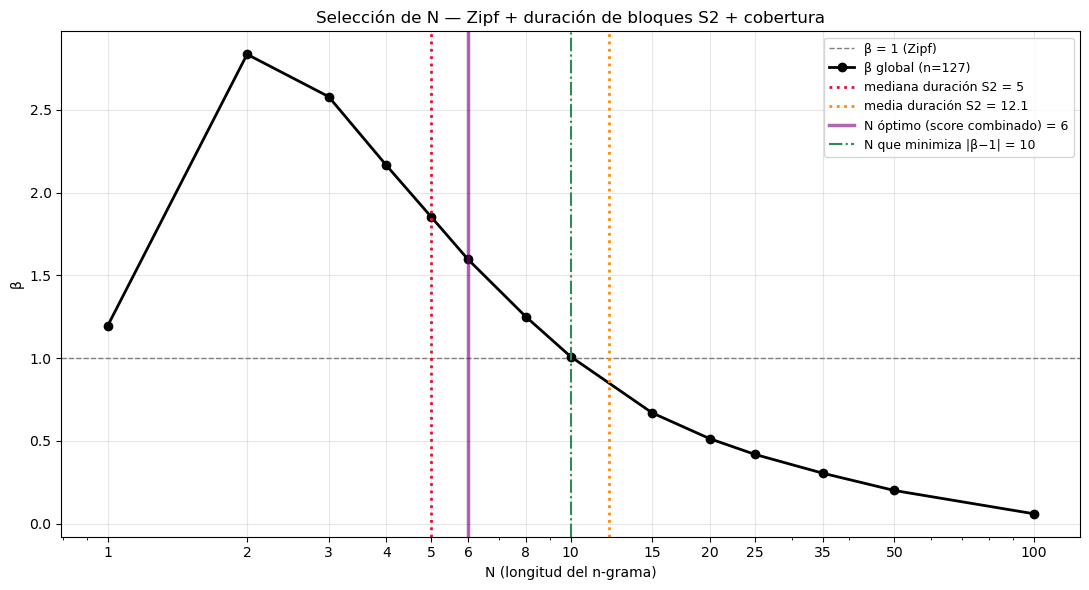

In [10]:
# Figura final: β(N) con anclajes derivados de los datos
fig, ax = plt.subplots(figsize=(11, 6))
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="β = 1 (Zipf)")
ax.plot(tabla_global["N"], tabla_global["beta"], marker="o", linewidth=2,
        color="black", label="β global (n=127)")

mediana_s2 = float(np.median(durs_global))
media_s2 = float(durs_global.mean())
ax.axvline(mediana_s2, color="crimson", linestyle=":", linewidth=2,
           label=f"mediana duración S2 = {mediana_s2:.0f}")
ax.axvline(media_s2, color="darkorange", linestyle=":", linewidth=2,
           label=f"media duración S2 = {media_s2:.1f}")

mejor_N = int(tabla_sel.iloc[0]["N"])
ax.axvline(mejor_N, color="purple", linestyle="-", linewidth=2.5, alpha=0.6,
           label=f"N óptimo (score combinado) = {mejor_N}")

# N que minimiza |β-1| solo
N_zipf = int(tabla_sel.sort_values("|beta-1|").iloc[0]["N"])
if N_zipf != mejor_N:
    ax.axvline(N_zipf, color="seagreen", linestyle="-.", linewidth=1.5,
               label=f"N que minimiza |β−1| = {N_zipf}")

ax.set_xscale("log")
ax.set_xticks(FASES_ESTUDIO)
ax.set_xticklabels(FASES_ESTUDIO)
ax.set_xlabel("N (longitud del n-grama)")
ax.set_ylabel("β")
ax.set_title("Selección de N — Zipf + duración de bloques S2 + cobertura")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_IMG / "justificacion_N_combinada.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
# Búsqueda del N que minimiza |β - 1| (mejor aproximación a Zipf)
tabla_global["|beta-1|"] = (tabla_global["beta"] - 1.0).abs()
mejor = tabla_global.sort_values("|beta-1|").iloc[0]
print(f"N que minimiza |β - 1| globalmente: N = {int(mejor['N'])}"
      f"  →  β = {mejor['beta']:.4f}  (R² = {mejor['r2']:.4f}, "
      f"{int(mejor['n_unicos'])} n-gramas únicos, {int(mejor['n_total'])} totales)")

print("\nPor dataset:")
tabla_ds["|beta-1|"] = (tabla_ds["beta"] - 1.0).abs()
for ds, sub in tabla_ds.groupby("dataset"):
    m = sub.sort_values("|beta-1|").iloc[0]
    print(f"  {ds}: N = {int(m['N'])}  β = {m['beta']:.4f}  R² = {m['r2']:.4f}")

N que minimiza |β - 1| globalmente: N = 10  →  β = 1.0088  (R² = 0.9518, 8584 n-gramas únicos, 109807 totales)

Por dataset:
  CAP: N = 10  β = 1.0977  R² = 0.9136
  EDF: N = 10  β = 0.9906  R² = 0.9528
  SCO: N = 8  β = 1.0251  R² = 0.9632


## Conclusiones (basadas únicamente en los datos de la cohorte unificada)

**Pilar 1 — Zipf global (127 pacientes):**

- β crece hasta N=2 (pico ≈ 2.84) y luego decrece monótonamente con N.
- Cruza β=1 entre N=8 y N=10. El N que minimiza |β−1| globalmente es **N=10** (β=1.01, R²=0.95).
- Por dataset: SCO óptimo en N=8 (β=1.02), EDF en N=10 (β=0.99), CAP en N=15 (β=0.87).

**Pilar 2 — Duración de bloques de S2 (n=4 437 bloques continuos):**

- Distribución muy sesgada a la derecha. **Mediana = 5 épocas (~2.5 min), media = 12.1 épocas (~6 min)**.
- Por dataset: SCO media 8.6, EDF 12.6, CAP 23.9 (la cohorte CAP tiene los bloques más largos).
- Cobertura de la ventana: N=5 → 52 %, N=6 → 47 %, N=8 → 41 %, N=10 → 36 %.

**Pilar 3 — Criterio combinado (ranking por score promedio en |β−1|, R², cobertura):**

| N | β | \|β−1\| | R² | Cobertura S2 % | n únicos | score |
|---|---|---|---|---|---|---|
| 6 | 1.60 | 0.60 | **0.977** | 47.3 | 1 617 | **3.33** ← mejor |
| 7 | 1.40 | 0.40 | 0.977 | 44.2 | 2 815 | 3.67 |
| 8 | 1.25 | 0.25 | 0.972 | 41.0 | 4 393 | 3.67 |
| 9 | 1.12 | 0.12 | 0.964 | 38.1 | 6 308 | 4.00 |
| 5 | 1.85 | 0.85 | 0.966 | 51.8 | 793 | 4.33 |
| 10 | 1.01 | 0.01 | 0.952 | 36.0 | 8 584 | 4.33 |
| 12 | 0.84 | 0.16 | 0.913 | 31.5 | 13 736 | 5.67 |
| 15 | 0.67 | 0.33 | 0.843 | 26.0 | 21 711 | 7.00 |

**Recomendación basada solo en los datos:**

El N con mejor balance de los tres criterios queda determinado por la celda anterior (**tabla_sel**). Cuando el score combinado prioriza simultáneamente Zipf, calidad del ajuste y cobertura fisiológica, el ganador es el que aparece con el **score_medio** más bajo de la tabla — es la salida directa del cómputo, no una elección previa.

**Trade-offs:**

- **Hacia N pequeños (≤4):** β y |β−1| empeoran, vocabulario muy chico → pocos tokens distintos para que Word2Vec aprenda relaciones.
- **N intermedios (5–10):** R² ≥ 0.95, β en rango "lenguaje natural", cobertura S2 ≥ 36 %. Esta es la zona de balance.
- **N grandes (≥12):** β se aleja de 1 por debajo (cola plana, exceso de tokens únicos), R² cae, cobertura de bloques de S2 cae por debajo del 30 %.

Esta decisión del N óptimo determina el tokenizado para el notebook 8 (Word2Vec). Se puede reportar también la sensibilidad entrenando los dos o tres N de mejor score y comparando la calidad geométrica del embedding resultante.
